<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 3.16e-04 | train loss 0.9642 acc 0.639 | val loss 0.8233 acc 0.748 *


[DenseNet-121] Epoch   2/100 | LR: 3.16e-04 | train loss 0.8329 acc 0.705 | val loss 0.6267 acc 0.792 *


[DenseNet-121] Epoch   3/100 | LR: 3.16e-04 | train loss 0.8157 acc 0.707 | val loss 0.6976 acc 0.710


[DenseNet-121] Epoch   4/100 | LR: 3.16e-04 | train loss 0.8077 acc 0.729 | val loss 0.6200 acc 0.789 *


[DenseNet-121] Epoch   5/100 | LR: 3.16e-04 | train loss 0.8066 acc 0.685 | val loss 0.5858 acc 0.774 *


...

[DenseNet-121] Epoch  35/100 | LR: 3.16e-05 | train loss 0.2433 acc 0.911 | val loss 0.4236 acc 0.839


[DenseNet-121] Epoch  36/100 | LR: 3.16e-05 | train loss 0.2776 acc 0.894 | val loss 0.4461 acc 0.815


[DenseNet-121] Epoch  37/100 | LR: 3.16e-05 | train loss 0.2437 acc 0.910 | val loss 0.4459 acc 0.836


[DenseNet-121] Epoch  38/100 | LR: 3.16e-05 | train loss 0.2632 acc 0.905 | val loss 0.4787 acc 0.812


[DenseNet-121] Epoch  39/100 | LR: 3.16e-05 | train loss 0.2347 acc 0.914 | val loss 0.4669 acc 0.824

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 39.

[DenseNet-121] Restored best checkpoint (val loss = 0.3809)


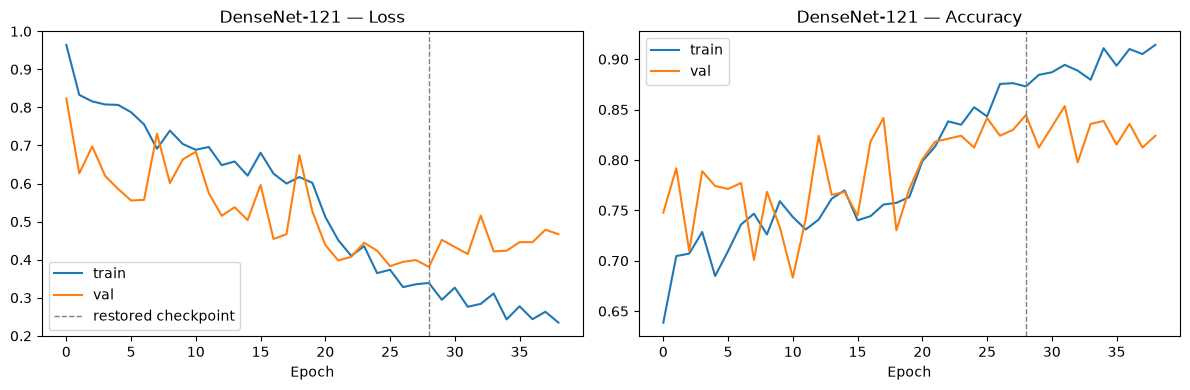

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.826


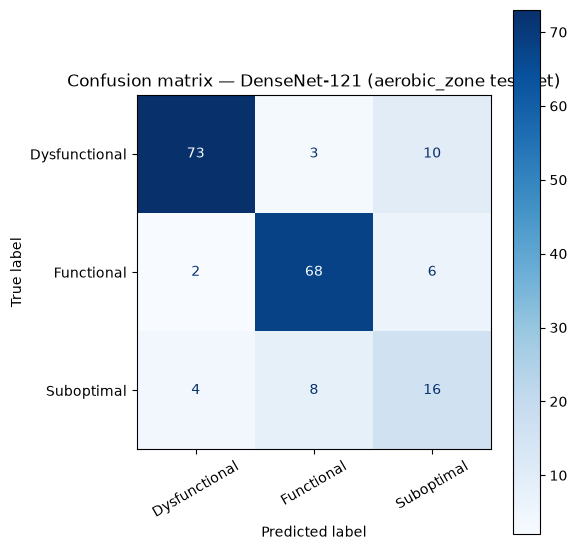

               precision    recall  f1-score   support

Dysfunctional      0.924     0.849     0.885        86
   Functional      0.861     0.895     0.877        76
   Suboptimal      0.500     0.571     0.533        28

     accuracy                          0.826       190
    macro avg      0.762     0.772     0.765       190
 weighted avg      0.836     0.826     0.830       190



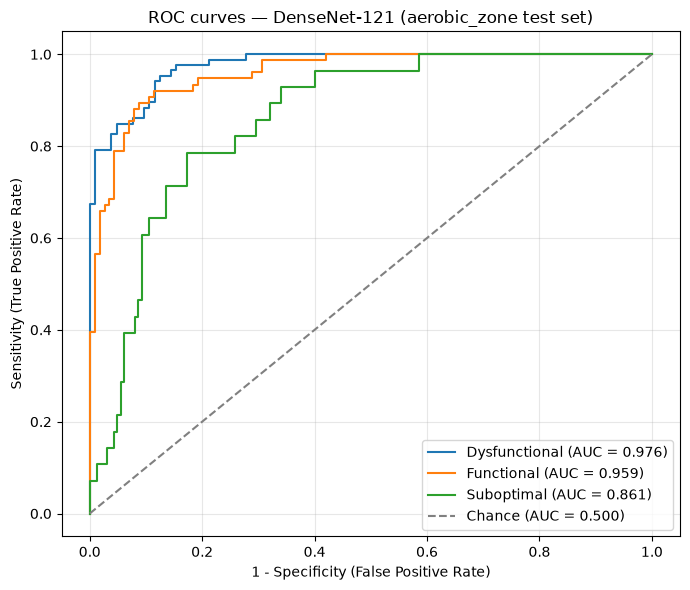

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.976
  Functional     : 0.959
  Suboptimal     : 0.861

Mean AUC (over 3/3 classes with test examples): 0.932


(np.float64(0.8263157894736842),
 {'Dysfunctional': 0.9760733452593917,
  'Functional': 0.958679593721145,
  'Suboptimal': 0.8608906525573192})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_densenet121_stratified.pkl


Saved model weights to ../models/aerobic_zone_densenet121_cnn.pt
